<a href="https://colab.research.google.com/github/Gars220/Proyecto_2_campo_profundo/blob/pipeline_sdss/sdss_extraction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%bash
# Servidor oficial de SDSS (DR18)
BASE_URL="http://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd="

# Query SQL ajustado para SkyServer
QUERY="SELECT s.class, s.z, s.ra, s.dec, p.u, p.g FROM dbo.fGetNearbyObjEq(135.5, 0.5, 30) AS n JOIN PhotoObj AS p ON n.objid = p.objid JOIN SpecObj AS s ON p.objid = s.bestobjid"

# Codificación de URL directamente con sed (reemplaza espacios, comas y paréntesis)
URL_ENCODED=$(echo "$QUERY" | sed \
  -e 's/ /%20/g' \
  -e 's/,/%2C/g' \
  -e 's/(/%28/g' \
  -e 's/)/%29/g')

# URL completa para consultar
FULL_URL="${BASE_URL}${URL_ENCODED}"

echo "URL generada:"
echo "$FULL_URL"

# Descargar el resultado a un archivo CSV
wget -q -O sdss_data.csv "$FULL_URL"

# Mostrar los primeros resultados
head -n 5 sdss_data.csv

URL generada:
http://skyserver.sdss.org/dr18/SkyServerWS/SearchTools/SqlSearch?format=csv&cmd=SELECT%20s.class%2C%20s.z%2C%20s.ra%2C%20s.dec%2C%20p.u%2C%20p.g%20FROM%20dbo.fGetNearbyObjEq%28135.5%2C%200.5%2C%2030%29%20AS%20n%20JOIN%20PhotoObj%20AS%20p%20ON%20n.objid%20=%20p.objid%20JOIN%20SpecObj%20AS%20s%20ON%20p.objid%20=%20s.bestobjid
#Table1
class,z,ra,dec,u,g
GALAXY,0.5209059,135.70602,0.81669628,20.85746,20.74581
GALAXY,0.5138233,135.73529,0.79774667,24.02483,22.56098
GALAXY,0.131484,135.86525,0.68853631,19.46726,18.34731


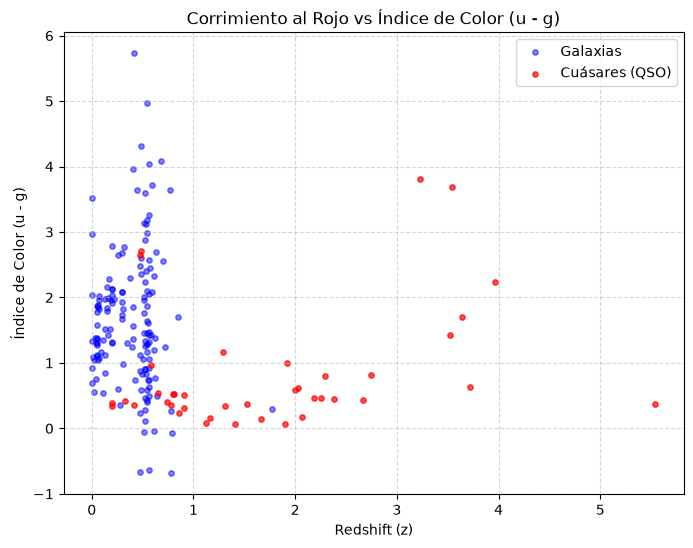

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('sdss_data.csv', header=1)

# Calculamos el índice de color
df['u-g'] = df['u'] - df['g']

# Filtrado de Galaxias y Cuásares
galaxies = df[df['class'] == 'GALAXY']
qso = df[df['class'] == 'QSO']


plt.figure(figsize=(8, 6))
plt.scatter(galaxies['z'], galaxies['u-g'], alpha=0.5, c='blue', label='Galaxias', s=15)
plt.scatter(qso['z'], qso['u-g'], alpha=0.7, c='red', label='Cuásares (QSO)', s=15)

plt.xlabel('Redshift (z)')
plt.ylabel('Índice de Color (u - g)')
plt.title('Corrimiento al Rojo vs Índice de Color (u - g)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
plt.savefig("sdss_data.png")

La utilizacion de git desde el colab ha sido asistida con IA